C:\Users\adibh\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


Number of cities: 100
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.009449
Start city: 17 | pseudo

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 100, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ graph_conv_1 (Lambda)                │ (None, 100, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ graph_conv_2 (Lambda)                │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ node_embeddings (Dense)              │ (None, 100, 32)             │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ edge_importance (Lambda)             │ (None, 100, 100)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,336 (9.12 KB)

 Trainable params: 2,336 (9.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0800 - loss: 0.9023
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.0700 - loss: 0.8792
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.0700 - loss: 0.8582
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.0700 - loss: 0.8392
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0700 - loss: 0.8222
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.0700 - loss: 0.8069
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0800 - loss: 0.7932
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0800 - loss: 0.7810
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.0800 - loss: 0.7704
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.0800 - loss: 0.7611
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.0800 - loss: 0.7530
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.0800 - loss

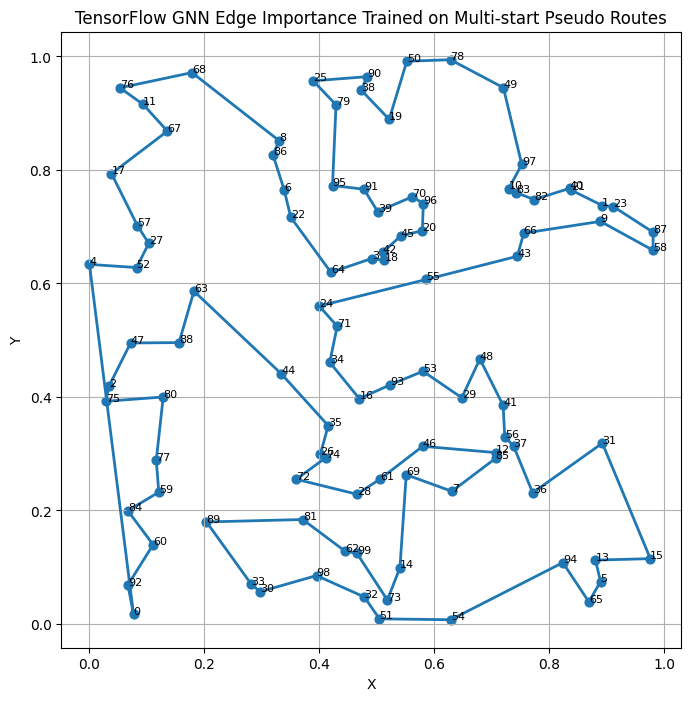

In [1]:
#TFGNN+BS+30-input

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.optimizers import Adam


df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)


def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D

distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)


K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1


A = A + np.eye(num_nodes, dtype=np.float32)

print("Adjacency shape:", A.shape)


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

A_hat_tf = tf.constant(
    A_hat,
    dtype=tf.float32
)

print("Normalized adjacency shape:", A_hat.shape)


avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)


def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route

#

def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total



def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best



NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)



all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)



Y_soft = np.mean(
    all_edge_labels,
    axis=0
).astype(np.float32)

np.fill_diagonal(Y_soft, 0)

print("Soft edge-label shape:", Y_soft.shape)
print("Soft label min:", Y_soft.min())
print("Soft label max:", Y_soft.max())



X_graph = np.expand_dims(
    X,
    axis=0
).astype(np.float32)

Y_graph = np.expand_dims(
    Y_soft,
    axis=0
).astype(np.float32)

print("X_graph shape:", X_graph.shape)
print("Y_graph shape:", Y_graph.shape)



inputs = Input(
    shape=(num_nodes, num_features)
)

def graph_convolution(x):

    return tf.matmul(
        A_hat_tf,
        x
    )

x = Lambda(
    graph_convolution,
    name="graph_conv_1"
)(inputs)

x = Dense(
    64,
    activation="relu",
    name="dense_1"
)(x)

x = Lambda(
    graph_convolution,
    name="graph_conv_2"
)(x)

embeddings = Dense(
    32,
    activation="relu",
    name="node_embeddings"
)(x)

def edge_score_layer(h):

    scores = tf.matmul(
        h,
        h,
        transpose_b=True
    )

    scores = tf.sigmoid(scores)

    return scores

outputs = Lambda(
    edge_score_layer,
    name="edge_importance"
)(embeddings)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()



history = model.fit(
    X_graph,
    Y_graph,
    epochs=300,
    verbose=1
)



edge_importance = model.predict(
    X_graph
)[0]

np.fill_diagonal(edge_importance, 0)

print("\nEdge importance shape:", edge_importance.shape)



distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)


def beam_search_route(cost_matrix, start=0, beam_width=5):

    n = len(cost_matrix)

    beams = [
        ([start], 0.0, set([start]))
    ]

    while True:

        new_beams = []

        for route, cost, visited in beams:

            if len(route) == n:

                final_cost = cost + cost_matrix[route[-1]][start]

                final_route = route + [start]

                new_beams.append(
                    (final_route, final_cost, visited)
                )

                continue

            current = route[-1]

            for nxt in range(n):

                if nxt not in visited:

                    new_route = route + [nxt]

                    new_cost = cost + cost_matrix[current][nxt]

                    new_visited = set(visited)

                    new_visited.add(nxt)

                    new_beams.append(
                        (new_route, new_cost, new_visited)
                    )

        new_beams = sorted(
            new_beams,
            key=lambda x: x[1]
        )

        beams = new_beams[:beam_width]

        if len(beams[0][0]) == n + 1:

            break

    return beams[0][0]


start_city = 0

gnn_route = beam_search_route(
    learned_cost,
    start=start_city,
    beam_width=5
)

print("\nGNN beam-search route distance before final 2-opt:")
print(
    route_distance(
        gnn_route,
        distance_matrix
    )
)

final_route = two_opt(
    gnn_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)


print("\n================ COMPARISON ================")

selected_start_index = start_cities.index(start_city)

same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + Beam Search + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")



route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "TensorFlow GNN Edge Importance Trained on Multi-start Pseudo Routes"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()

Number of cities: 100
Distance matrix shape: (100, 100)
Adjacency shape: (100, 100)
Normalized adjacency shape: (100, 100)
Node feature shape: (100, 3)
Start city: 0 | pseudo route distance: 8.466965
Start city: 1 | pseudo route distance: 7.880031
Start city: 2 | pseudo route distance: 8.030834
Start city: 3 | pseudo route distance: 8.162343
Start city: 4 | pseudo route distance: 7.9357576
Start city: 5 | pseudo route distance: 8.250826
Start city: 6 | pseudo route distance: 7.9867287
Start city: 7 | pseudo route distance: 8.37647
Start city: 8 | pseudo route distance: 8.047838
Start city: 9 | pseudo route distance: 7.9274263
Start city: 10 | pseudo route distance: 8.216549
Start city: 11 | pseudo route distance: 8.084217
Start city: 12 | pseudo route distance: 8.034227
Start city: 13 | pseudo route distance: 9.044995
Start city: 14 | pseudo route distance: 8.309969
Start city: 15 | pseudo route distance: 8.396156
Start city: 16 | pseudo route distance: 8.009449
Start city: 17 | pseudo

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 100, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ graph_conv_1 (Lambda)                │ (None, 100, 3)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 100, 64)             │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ graph_conv_2 (Lambda)                │ (None, 100, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ node_embeddings (Dense)              │ (None, 100, 32)             │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ edge_importance (Lambda)             │ (None, 100, 100)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,336 (9.12 KB)

 Trainable params: 2,336 (9.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1300 - loss: 0.8582
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.1400 - loss: 0.8389
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1200 - loss: 0.8214
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.1100 - loss: 0.8056
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.1100 - loss: 0.7914
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.1100 - loss: 0.7787
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1100 - loss: 0.7673
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.1200 - loss: 0.7572
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.1200 - loss: 0.7483
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.1200 - loss: 0.7405
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.1200 - loss: 0.7336
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.1200 - loss

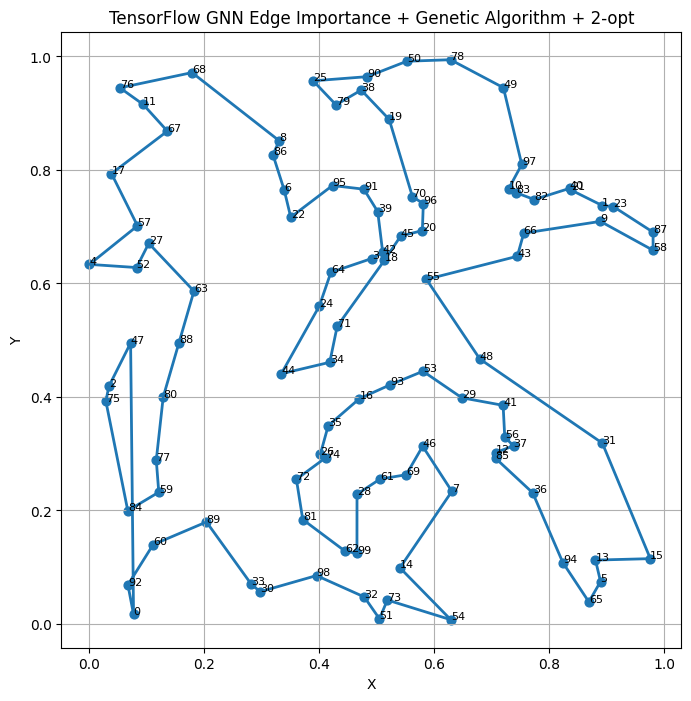

In [2]:
#TFGNN+GA+30-input

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Lambda
from tensorflow.keras.optimizers import Adam



df = pd.read_csv("large.csv", header=None)

coords = df.values.astype(np.float32)

N_SAMPLE = 100
coords = coords[:N_SAMPLE]

num_nodes = len(coords)

print("Number of cities:", num_nodes)



def compute_distance_matrix(coords):
    diff = coords[:, None, :] - coords[None, :, :]
    D = np.sqrt(np.sum(diff ** 2, axis=-1))
    return D

distance_matrix = compute_distance_matrix(coords)

print("Distance matrix shape:", distance_matrix.shape)



K = 10

A = np.zeros((num_nodes, num_nodes), dtype=np.float32)

for i in range(num_nodes):

    nearest = np.argsort(distance_matrix[i])[1:K + 1]

    for j in nearest:

        A[i][j] = 1
        A[j][i] = 1

A = A + np.eye(num_nodes, dtype=np.float32)

print("Adjacency shape:", A.shape)


degree = np.sum(A, axis=1)

D_inv_sqrt = np.diag(
    1.0 / np.sqrt(degree + 1e-8)
)

A_hat = D_inv_sqrt @ A @ D_inv_sqrt

A_hat_tf = tf.constant(
    A_hat,
    dtype=tf.float32
)

print("Normalized adjacency shape:", A_hat.shape)



avg_distance = np.mean(
    distance_matrix,
    axis=1
).reshape(-1, 1)

X = np.hstack([
    coords,
    avg_distance
]).astype(np.float32)

X = (
    X - X.mean(axis=0)
) / (
    X.std(axis=0) + 1e-8
)

num_features = X.shape[1]

print("Node feature shape:", X.shape)



def nearest_neighbor_route(D, start=0):

    n = len(D)

    visited = set([start])

    route = [start]

    current = start

    while len(route) < n:

        best_node = None
        best_dist = float("inf")

        for j in range(n):

            if j not in visited:

                if D[current][j] < best_dist:

                    best_dist = D[current][j]
                    best_node = j

        route.append(best_node)

        visited.add(best_node)

        current = best_node

    route.append(start)

    return route



def route_distance(route, D):

    total = 0

    for i in range(len(route) - 1):

        total += D[route[i]][route[i + 1]]

    return total


def two_opt(route, D, max_iter=50):

    best = route[:]

    best_distance = route_distance(best, D)

    improved = True

    iteration = 0

    while improved and iteration < max_iter:

        improved = False

        iteration += 1

        for i in range(1, len(best) - 2):

            for j in range(i + 1, len(best) - 1):

                if j - i == 1:
                    continue

                new_route = best[:]

                new_route[i:j] = reversed(new_route[i:j])

                new_distance = route_distance(new_route, D)

                if new_distance < best_distance:

                    best = new_route

                    best_distance = new_distance

                    improved = True

    return best



NUM_STARTS = min(num_nodes, 30)

start_cities = list(range(NUM_STARTS))

pseudo_routes = []

pseudo_distances = []

for start in start_cities:

    initial_route = nearest_neighbor_route(
        distance_matrix,
        start=start
    )

    pseudo_route = two_opt(
        initial_route,
        distance_matrix,
        max_iter=20
    )

    pseudo_routes.append(pseudo_route)

    dist = route_distance(
        pseudo_route,
        distance_matrix
    )

    pseudo_distances.append(dist)

    print(
        "Start city:",
        start,
        "| pseudo route distance:",
        dist
    )

print("\nTotal pseudo routes generated:", len(pseudo_routes))

best_route_index = np.argmin(pseudo_distances)

best_pseudo_route = pseudo_routes[best_route_index]

best_pseudo_distance = pseudo_distances[best_route_index]

print("\nBest pseudo route start city:", start_cities[best_route_index])
print("Best pseudo route distance:", best_pseudo_distance)


all_edge_labels = []

for pseudo_route in pseudo_routes:

    edge_labels = np.zeros(
        (num_nodes, num_nodes),
        dtype=np.float32
    )

    for i in range(len(pseudo_route) - 1):

        u = pseudo_route[i]
        v = pseudo_route[i + 1]

        edge_labels[u][v] = 1
        edge_labels[v][u] = 1

    all_edge_labels.append(edge_labels)

all_edge_labels = np.array(
    all_edge_labels,
    dtype=np.float32
)

print("\nAll edge labels shape:", all_edge_labels.shape)



Y_soft = np.mean(
    all_edge_labels,
    axis=0
).astype(np.float32)

np.fill_diagonal(Y_soft, 0)

print("Soft edge-label shape:", Y_soft.shape)
print("Soft label min:", Y_soft.min())
print("Soft label max:", Y_soft.max())


X_graph = np.expand_dims(
    X,
    axis=0
).astype(np.float32)

Y_graph = np.expand_dims(
    Y_soft,
    axis=0
).astype(np.float32)

print("X_graph shape:", X_graph.shape)
print("Y_graph shape:", Y_graph.shape)



inputs = Input(
    shape=(num_nodes, num_features)
)

def graph_convolution(x):

    return tf.matmul(
        A_hat_tf,
        x
    )

x = Lambda(
    graph_convolution,
    name="graph_conv_1"
)(inputs)

x = Dense(
    64,
    activation="relu",
    name="dense_1"
)(x)

x = Lambda(
    graph_convolution,
    name="graph_conv_2"
)(x)

embeddings = Dense(
    32,
    activation="relu",
    name="node_embeddings"
)(x)

def edge_score_layer(h):

    scores = tf.matmul(
        h,
        h,
        transpose_b=True
    )

    scores = tf.sigmoid(scores)

    return scores

outputs = Lambda(
    edge_score_layer,
    name="edge_importance"
)(embeddings)

model = Model(
    inputs=inputs,
    outputs=outputs
)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


history = model.fit(
    X_graph,
    Y_graph,
    epochs=300,
    verbose=1
)


edge_importance = model.predict(
    X_graph
)[0]

np.fill_diagonal(edge_importance, 0)

print("\nEdge importance shape:", edge_importance.shape)



distance_norm = distance_matrix / (
    distance_matrix.max() + 1e-8
)

epsilon = 1e-6

learned_cost = distance_matrix / (edge_importance + epsilon)

np.fill_diagonal(learned_cost, 1e9)

print("Learned cost shape:", learned_cost.shape)



def create_individual(num_nodes, start):

    cities = [
        city for city in range(num_nodes)
        if city != start
    ]

    np.random.shuffle(cities)

    return cities


def individual_to_route(individual, start):

    route = [start] + individual + [start]

    return route


def fitness(individual, cost_matrix, start):

    route = individual_to_route(
        individual,
        start
    )

    return route_distance(
        route,
        cost_matrix
    )


def tournament_selection(
    population,
    cost_matrix,
    start,
    k=3
):

    selected_indices = np.random.choice(
        len(population),
        k,
        replace=False
    )

    best_individual = None

    best_cost = float("inf")

    for idx in selected_indices:

        individual = population[idx]

        current_cost = fitness(
            individual,
            cost_matrix,
            start
        )

        if current_cost < best_cost:

            best_cost = current_cost

            best_individual = individual

    return best_individual.copy()


def order_crossover(parent1, parent2):

    n = len(parent1)

    a, b = sorted(
        np.random.choice(
            n,
            2,
            replace=False
        )
    )

    child = [-1] * n

    child[a:b] = parent1[a:b]

    pointer = b

    for city in parent2:

        if city not in child:

            if pointer >= n:

                pointer = 0

            child[pointer] = city

            pointer += 1

    return child


def mutate(individual, mutation_rate=0.2):

    if np.random.rand() < mutation_rate:

        i, j = np.random.choice(
            len(individual),
            2,
            replace=False
        )

        individual[i], individual[j] = individual[j], individual[i]

    return individual


def genetic_algorithm_route(
    cost_matrix,
    start=0,
    seed_route=None,
    population_size=100,
    generations=300,
    mutation_rate=0.2
):

    population = [
        create_individual(num_nodes, start)
        for _ in range(population_size)
    ]

   
    if seed_route is not None:

        seed_individual = seed_route[1:-1]

        population[0] = seed_individual.copy()

    best_individual = None

    best_cost = float("inf")

    for gen in range(generations):

        new_population = []

        for individual in population:

            current_cost = fitness(
                individual,
                cost_matrix,
                start
            )

            if current_cost < best_cost:

                best_cost = current_cost

                best_individual = individual.copy()

        new_population.append(
            best_individual.copy()
        )

        while len(new_population) < population_size:

            parent1 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            parent2 = tournament_selection(
                population,
                cost_matrix,
                start,
                k=3
            )

            child = order_crossover(
                parent1,
                parent2
            )

            child = mutate(
                child,
                mutation_rate=mutation_rate
            )

            new_population.append(child)

        population = new_population

        if gen % 50 == 0:

            print(
                "GA generation:",
                gen,
                "| best learned cost:",
                best_cost
            )

    best_route = individual_to_route(
        best_individual,
        start
    )

    return best_route



start_city = 0

selected_start_index = start_cities.index(start_city)

same_start_pseudo_route = pseudo_routes[selected_start_index]

same_start_pseudo_distance = pseudo_distances[selected_start_index]

ga_route = genetic_algorithm_route(
    learned_cost,
    start=start_city,
    seed_route=same_start_pseudo_route,
    population_size=100,
    generations=300,
    mutation_rate=0.2
)

print("\nGNN + GA route distance before final 2-opt:")
print(
    route_distance(
        ga_route,
        distance_matrix
    )
)

final_route = two_opt(
    ga_route,
    distance_matrix,
    max_iter=20
)

final_distance = route_distance(
    final_route,
    distance_matrix
)

print("\nFinal Route:")
print(final_route)

print("\nFinal Route Distance:")
print(final_distance)



print("\n================ COMPARISON ================")

print("Selected start city:")
print(start_city)

print("\nPseudo route distance for this start city:")
print(same_start_pseudo_distance)

print("\nGNN + GA + 2-opt final distance:")
print(final_distance)

if final_distance < same_start_pseudo_distance:

    improvement = (
        (same_start_pseudo_distance - final_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nGNN + GA final route is better than pseudo route of same start city.")
    print("Improvement (%):", improvement)

elif final_distance > same_start_pseudo_distance:

    worsening = (
        (final_distance - same_start_pseudo_distance)
        / same_start_pseudo_distance
    ) * 100

    print("\nPseudo route of same start city is better.")
    print("GNN + GA final route is worse by (%):", worsening)

else:

    print("\nBoth routes have the same distance.")



route_coords = coords[final_route]

plt.figure(figsize=(8, 8))

plt.scatter(
    coords[:, 0],
    coords[:, 1],
    s=40
)

plt.plot(
    route_coords[:, 0],
    route_coords[:, 1],
    linewidth=2
)

for i in range(num_nodes):

    plt.text(
        coords[i, 0],
        coords[i, 1],
        str(i),
        fontsize=8
    )

plt.title(
    "TensorFlow GNN Edge Importance + Genetic Algorithm + 2-opt"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.grid(True)

plt.show()